In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
upload = files.upload()

Saving free time vs uni (Responses).csv to free time vs uni (Responses).csv


In [3]:
df = pd.read_csv('free time vs uni (Responses).csv')
df.head()

,Timestamp,gender,major,year,"do you have some thing that already takes up most of your available free time ?(work, health condition etc.)",did you used to go out/have free time before university started?,how much free time did you have before starting university?(on avg.),how did that change after joining university?,what (if anything) did you have to give up when university started because of the lack of time?,how long do you spend studying daily?,do you feel as that your major compared to other majors impacts your access to free time ?,how long is your commute to university?,how long does university as a whole take up from your time?
0,4/5/2026 16:34:15,male,computer science,2,yes,yes,more than 4 hrs / all the free time you wanted,decreased alot,training / gym,3 or more hrs,No,less than 30 mins,most of the day
1,4/5/2026 16:34:31,Female,computer science,2,yes,yes,3-4 hrs a day / going out or going to the gym ...,decreased slightly,training / gym,2 hrs,Yes,1 hr,most of the day
2,4/5/2026 16:35:12,male,computer science,2,yes,yes,1-2 hrs a day / doing something you like or ha...,decreased alot,training / gym,3 or more hrs,Yes,2 or more hrs,most of the day
3,4/5/2026 16:36:26,Female,computer science,2,no,yes,3-4 hrs a day / going out or going to the gym ...,decreased alot,hobbies,1 hr,Yes,1 hr,most of the day
4,4/5/2026 16:37:25,Female,computer science,2,yes,yes,3-4 hrs a day / going out or going to the gym ...,stayed the same,hobbies,3 or more hrs,Yes,1 hr,most of the day


Basic Calculations And visual Representations of columns

In [4]:
df['gender'].value_counts()

,count
gender,
Female,32
male,19


In [5]:
df['year'].value_counts()

,count
year,
2,41
4,6
3,3
1,1


In [6]:
df['major'].value_counts()

,count
major,
computer science,34
business informatics,9
digital arts,5
engineering,3


In [7]:
df['did you used to go out/have free time before university started?'].value_counts()

,count
did you used to go out/have free time before university started?,
yes,47
no,4


In [123]:

mapping = {
    '0 hrs / no time at all': 0,
    '1-2 hrs a day / doing something you like or having me time': 1.5,
    '3-4 hrs a day / going out or going to the gym regularly': 3.5,
    'more than 4 hrs / all the free time you wanted': 5
}

df['FreeTimeBefore'] = df['how much free time did you have before starting university?(on avg.)'].map(mapping)
mean_val = df['FreeTimeBefore'].mean()
std = df['FreeTimeBefore'].std()
mode = df['how much free time did you have before starting university?(on avg.)'].mode()
median=df['FreeTimeBefore'].median()
print(median)
print(mode)
print(mean_val)
print(std)

3.5
0    3-4 hrs a day / going out or going to the gym ...
Name: how much free time did you have before starting university?(on avg.), dtype: object
3.696078431372549
1.2044850824005622


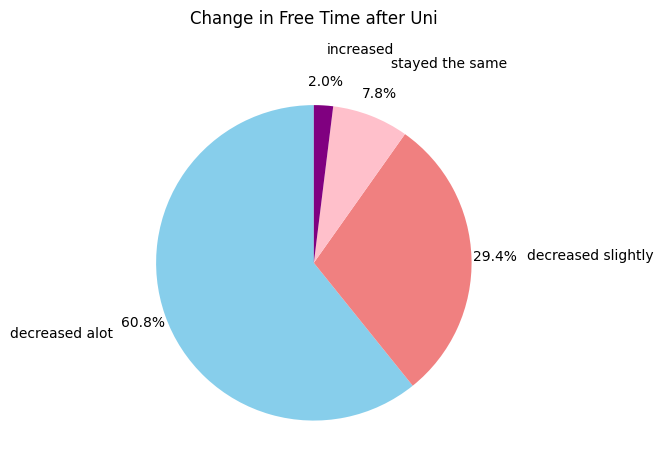

In [17]:
count = df['how did that change after joining university?'].value_counts()
plt.pie(count, labels= count.index,
        autopct = '%1.1f%%',
        colors=['skyblue','lightcoral','pink','purple'],
        startangle=90,
        pctdistance=1.15,
        labeldistance=1.35,
        )
plt.title('Change in Free Time after Uni',pad=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6275/2328458404.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(['0', '1 - 2', '3 - 4', '4+'])


Text(0.5, 1.0, 'Free Time before Uni')

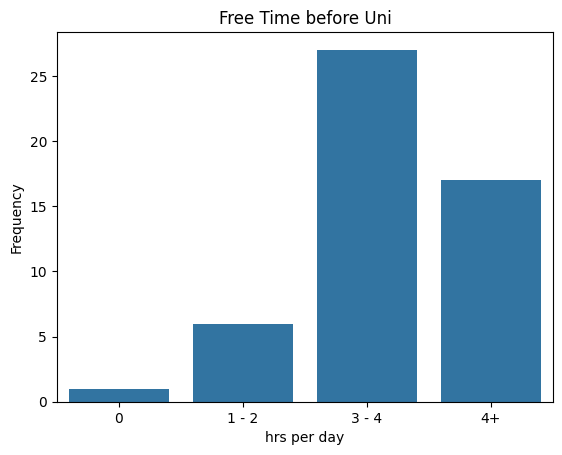

In [66]:
chart = sns.countplot(data = df, x='how much free time did you have before starting university?(on avg.)',
                      order=['0 hrs / no time at all',
                     '1-2 hrs a day / doing something you like or having me time',
                     '3-4 hrs a day / going out or going to the gym regularly',
                     'more than 4 hrs / all the free time you wanted'])
chart.set_xticklabels(['0', '1 - 2', '3 - 4', '4+'])
chart.set_xlabel('hrs per day')
chart.set_ylabel('Frequency')
chart.set_title('Free Time before Uni')

Text(0, 0.5, 'Frequency')

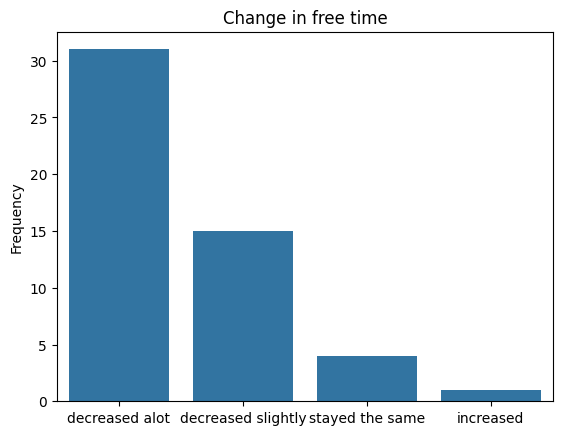

In [108]:
plot = sns.countplot(data = df, x = 'how did that change after joining university?')
plot.set_xlabel('')
plot.set_title('Change in free time')
plot.set_ylabel('Frequency')


1- Free time vs. Gender

In [68]:
pd.crosstab(df['gender'],df['did you used to go out/have free time before university started?'])

did you used to go out/have free time before university started?,no,yes
gender,,
Female,1,31
male,3,16


In [71]:
pct_table = pd.crosstab(df['gender'], df['did you used to go out/have free time before university started?'], normalize='index') * 100

print(pct_table)

did you used to go out/have free time before university started?         no  \
gender                                                                        
Female                                                             3.125000   
male                                                              15.789474   

did you used to go out/have free time before university started?        yes  
gender                                                                       
Female                                                            96.875000  
male                                                              84.210526  


In [44]:
df['how much free time did you have before starting university?(on avg.)'].value_counts()


,count
how much free time did you have before starting university?(on avg.),
3-4 hrs a day / going out or going to the gym regularly,27
more than 4 hrs / all the free time you wanted,17
1-2 hrs a day / doing something you like or having me time,6
0 hrs / no time at all,1


In [92]:
pd.crosstab(df['gender'], df['how much free time did you have before starting university?(on avg.)'])


how much free time did you have before starting university?(on avg.),0 hrs / no time at all,1-2 hrs a day / doing something you like or having me time,3-4 hrs a day / going out or going to the gym regularly,more than 4 hrs / all the free time you wanted
gender,,,,
Female,1,1,21,9
male,0,5,6,8


Text(0.5, 1.0, 'Gender vs. Free Time Before Uni')

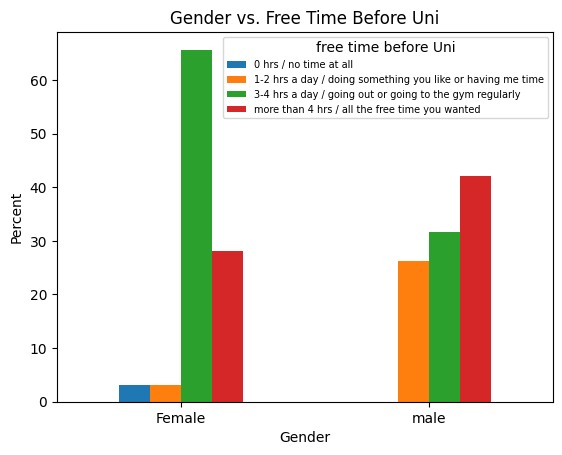

In [93]:
pct_table = pd.crosstab(df['gender'], df['how much free time did you have before starting university?(on avg.)'], normalize='index') * 100
pct_table.plot(kind='bar')
plt.legend(title='free time before Uni',fontsize=7)
plt.xticks(rotation=0)
plt.xlabel('Gender')
plt.ylabel ('Percent')
plt.title('Gender vs. Free Time Before Uni')


In [94]:
print(pct_table)

how much free time did you have before starting university?(on avg.)  0 hrs / no time at all  \
gender                                                                                         
Female                                                                                 3.125   
male                                                                                   0.000   

how much free time did you have before starting university?(on avg.)  1-2 hrs a day / doing something you like or having me time  \
gender                                                                                                                             
Female                                                                                                         3.125000            
male                                                                                                          26.315789            

how much free time did you have before starting university?(on avg.)  3-4 hrs a day / 

In [27]:
pd.crosstab(df['gender'],df['how did that change after joining university?'])

how did that change after joining university?,decreased alot,decreased slightly,increased,stayed the same
gender,,,,
Female,18,11,0,3
male,13,4,1,1


how did that change after joining university?  decreased alot  \
gender                                                          
Female                                              56.250000   
male                                                68.421053   

how did that change after joining university?  decreased slightly  increased  \
gender                                                                         
Female                                                  34.375000   0.000000   
male                                                    21.052632   5.263158   

how did that change after joining university?  stayed the same  
gender                                                          
Female                                                9.375000  
male                                                  5.263158  


Text(0, 0.5, 'Percent')

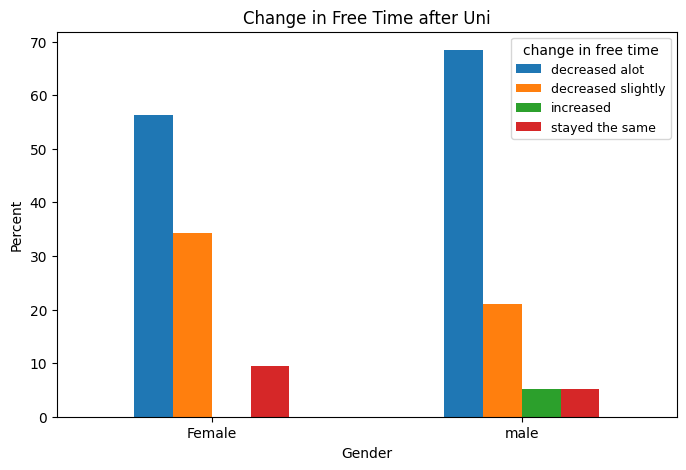

In [95]:
pct_table = pd.crosstab(df['gender'], df['how did that change after joining university?'], normalize='index') * 100
print(pct_table)
pct_table.plot(kind='bar',figsize=(8, 5))
plt.legend(title='change in free time',fontsize=9)
plt.title('Change in Free Time after Uni')
plt.xticks(rotation = 0)
plt.xlabel('Gender')
plt.ylabel('Percent')

Text(0.5, 1.0, 'Gender vs. Free Time before Uni')

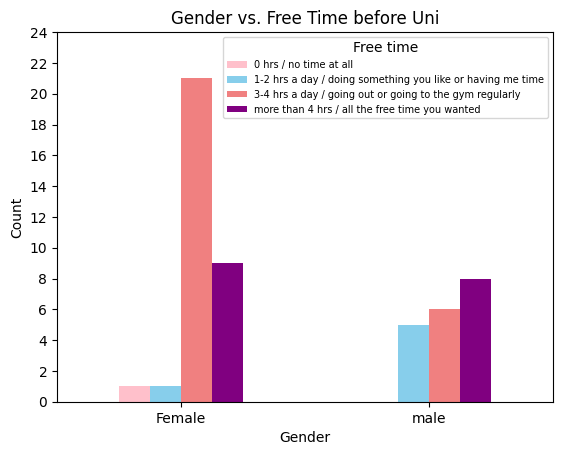

In [110]:
count_table = pd.crosstab(df['gender'], df['how much free time did you have before starting university?(on avg.)'])
count_table.plot(kind='bar', color=['pink','skyblue','lightcoral','purple'])
plt.yticks(np.arange(0, 25, 2))
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.legend(title='Free time',fontsize=7)
plt.title('Gender vs. Free Time before Uni')

do you have some thing that already takes up most of your available free time ?(work, health condition etc.)
yes    33
no     18
Name: count, dtype: int64


(array([0, 1]), [Text(0, 0, 'Female'), Text(1, 0, 'male')])

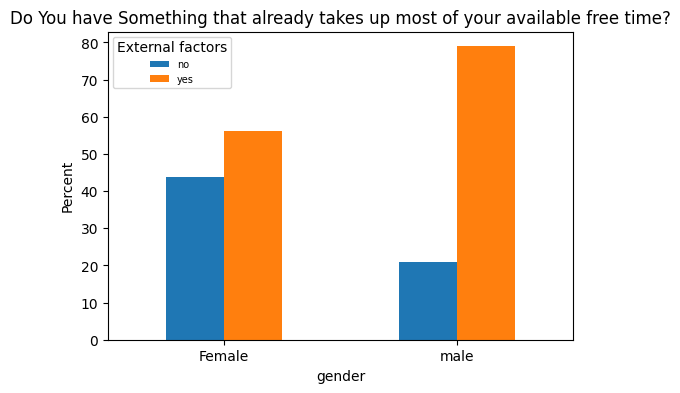

In [135]:
print(df['do you have some thing that already takes up most of your available free time ?(work, health condition etc.)'].value_counts())
tab = pd.crosstab(df['gender'], df['do you have some thing that already takes up most of your available free time ?(work, health condition etc.)'], normalize='index') * 100
tab.plot(kind='bar',figsize=(6,4))
plt.title('Do You have Something that already takes up most of your available free time?')
plt.legend(title='External factors',fontsize=7)
plt.ylabel('Percent')
plt.xticks(rotation = 0)

In [14]:
df['do you feel as that your major compared to other majors impacts your access to free time ?'].value_counts()

,count
do you feel as that your major compared to other majors impacts your access to free time ?,
Yes,38
No,13


Text(0.5, 1.0, 'Gender vs. change in free time')

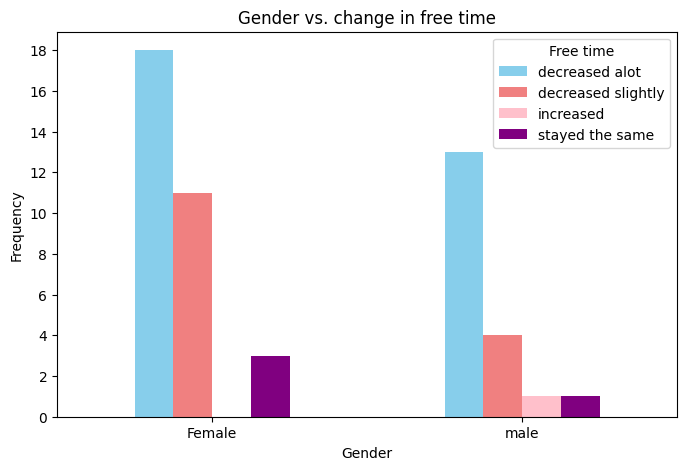

In [129]:
count_table = pd.crosstab(df['gender'], df['how did that change after joining university?'])
ax = count_table.plot(kind='bar',figsize=(8, 5), color=['skyblue','lightcoral','pink','purple'])
plt.yticks(np.arange(0, 20, 2))
plt.xticks(rotation = 0)
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.legend(title='Free time')
plt.title('Gender vs. change in free time')

2- Free time vs. Major

Text(0.5, 1.0, 'major vs. Free Time')

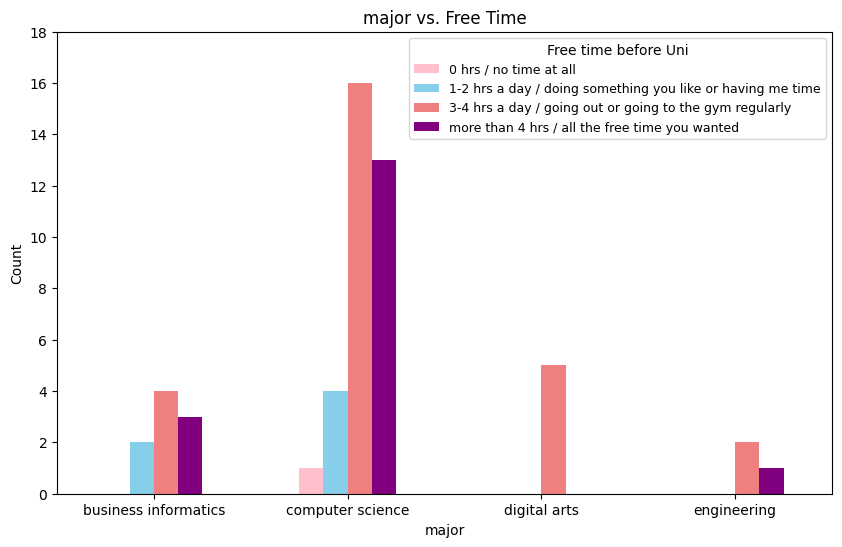

In [136]:
count_table = pd.crosstab(df['major'], df['how much free time did you have before starting university?(on avg.)'])
ax = count_table.plot(kind='bar', stacked=False,figsize=(10, 6), color=['pink','skyblue','lightcoral','purple'])
plt.yticks(np.arange(0, 20, 2))
plt.xticks(rotation = 0)
plt.xlabel('major')
plt.ylabel('Count')
plt.legend(title='Free time before Uni',fontsize=9)
plt.title('major vs. Free Time')

Text(0.5, 1.0, 'major vs. Free Time after Uni')

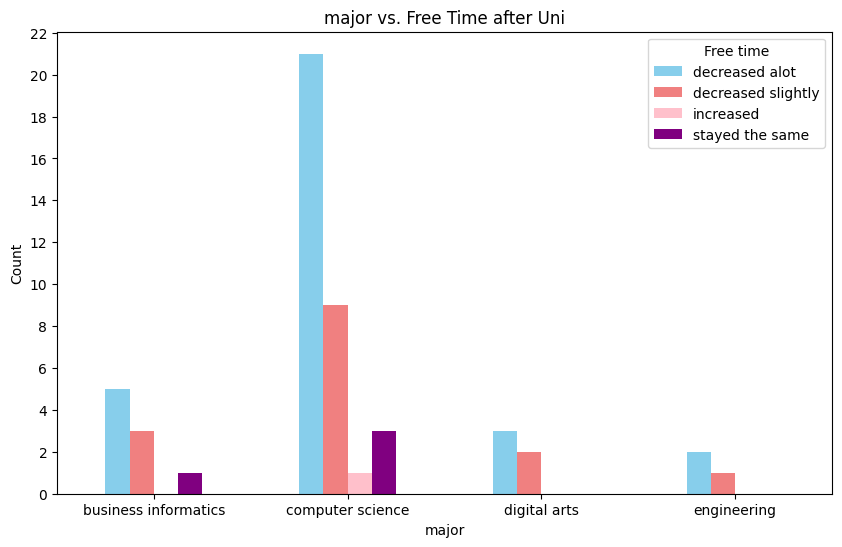

In [137]:
count_table = pd.crosstab(df['major'], df['how did that change after joining university?'])
ax = count_table.plot(kind='bar', stacked=False,figsize=(10, 6), color=['skyblue','lightcoral','pink','purple'])
plt.yticks(np.arange(0, 24, 2))
plt.xticks(rotation = 0)
plt.xlabel('major')
plt.ylabel('Count')
plt.legend(title='Free time')
plt.title('major vs. Free Time after Uni')

3- Free time vs. Academic year

Text(0.5, 1.0, 'Year vs. Free Time before Uni')

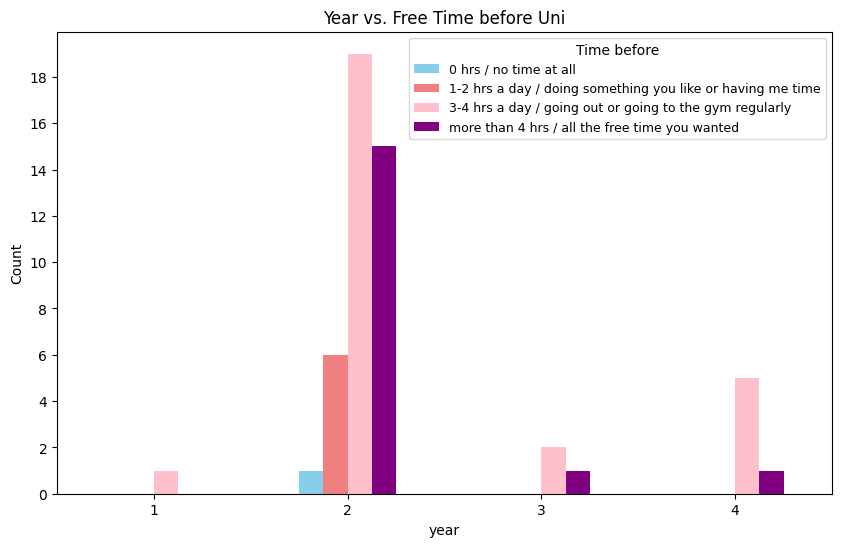

In [138]:
count_table = pd.crosstab(df['year'], df['how much free time did you have before starting university?(on avg.)'])
ax = count_table.plot(kind='bar', stacked=False,figsize=(10, 6), color=['skyblue','lightcoral','pink','purple'])
plt.yticks(np.arange(0, 20, 2))
plt.xticks(rotation = 0)
plt.xlabel('year')
plt.ylabel('Count')
plt.legend(title='Time before',fontsize=9)
plt.title('Year vs. Free Time before Uni')

Text(0.5, 1.0, 'year vs. Free Time')

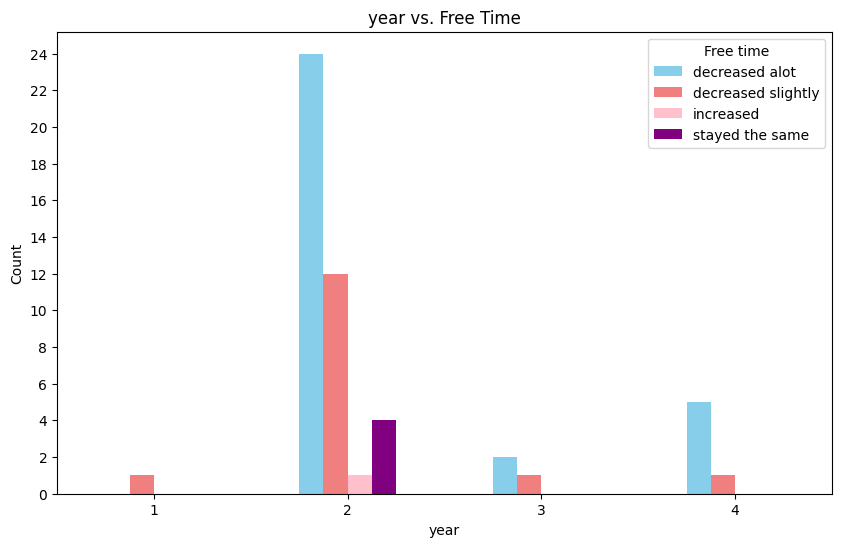

In [139]:
count_table = pd.crosstab(df['year'], df['how did that change after joining university?'])
ax = count_table.plot(kind='bar', stacked=False,figsize=(10, 6), color=['skyblue','lightcoral','pink','purple'])
plt.yticks(np.arange(0, 26, 2))
plt.xticks(rotation = 0)
plt.xlabel('year')
plt.ylabel('Count')
plt.legend(title='Free time')
plt.title('year vs. Free Time')

In [22]:
df['year'].value_counts()

,count
year,
2,41
4,6
3,3
1,1


In [23]:
pd.crosstab(df['year'], df['how much free time did you have before starting university?(on avg.)'])


how much free time did you have before starting university?(on avg.),0 hrs / no time at all,1-2 hrs a day / doing something you like or having me time,3-4 hrs a day / going out or going to the gym regularly,more than 4 hrs / all the free time you wanted
year,,,,
1,0,0,1,0
2,1,6,19,15
3,0,0,2,1
4,0,0,5,1


In [24]:
pd.crosstab(df['year'], df['how did that change after joining university?'])

how did that change after joining university?,decreased alot,decreased slightly,increased,stayed the same
year,,,,
1,0,1,0,0
2,24,12,1,4
3,2,1,0,0
4,5,1,0,0


4- what had to be given up

In [143]:
df['what (if anything) did you have to give up when university started because of the lack of time?'].unique()

array(['training / gym', 'hobbies', 'nothing',
       "I cut back on things but didn't give them up fully", 'other'],
      dtype=object)

In [161]:
df['what (if anything) did you have to give up when university started because of the lack of time?'].value_counts(normalize = True)*100


,proportion
what (if anything) did you have to give up when university started because of the lack of time?,
I cut back on things but didn't give them up fully,31.372549
training / gym,25.490196
hobbies,21.568627
nothing,17.647059
other,3.921569


/tmp/ipykernel_6275/3557094717.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(['Hobbies', 'Training', 'cut back but not fully', 'Other','Nothing'], fontsize = 9)


Text(0, 0.5, 'Frequency')

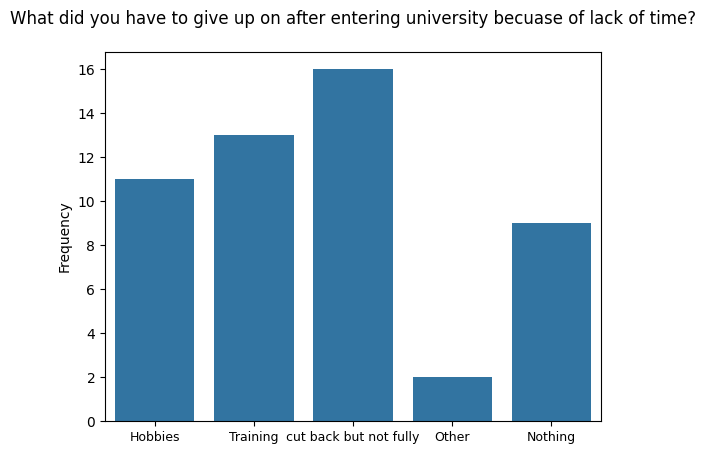

In [169]:
amount = df['what (if anything) did you have to give up when university started because of the lack of time?'].value_counts()
p = sns.countplot(data = df, x = 'what (if anything) did you have to give up when university started because of the lack of time?',
order = ['hobbies', 'training / gym', "I cut back on things but didn't give them up fully",'other','nothing'])
p.set_xticklabels(['Hobbies', 'Training', 'cut back but not fully', 'Other','Nothing'], fontsize = 9)
p.set_title('What did you have to give up on after entering university becuase of lack of time?', pad = 20)
p.set_xlabel('')
p.set_ylabel('Frequency')
